#### t-SNE
- 비선형 차원 축소 기법으로 고차원의 데이터를 국소 구조를 보존하면서 2차원 또는 3차원 시각화를 하기 위해 사용 
- 고차원 데이터의 경우에는 거리 기반 유사도(가우시안 분포를 이용한 계산)
- 저차원의 경우에는 확률적으로 비슷하게 재현(t-분포를 이용한 계산)
    - t-분포를 사용하는 이유는 멀리 떨어진 점간의 거리 차이를 완화시키기 위한 방법 

- 거리 계산 방법
    - 유클리드 거리(euclidean) -> 기본적인 거리 방식 (직선의 거리) -> 수치형 데이터에서 사용
    - 맨헤튼 거리(manhattan) -> 직각 축 기반 거리 
    - 체비쇼프 거리(chebyshev) -> 최대의 축 차이 기반 
    - 코사인 거리(유사도)(cosine) -> 벡터 방향 기반 -> 자연어 데이터에서 사용
    - 마할라노비스 거리(mahalanobis) -> 변수 간 상관 반영

- parameter
    - n_components
        - 기본값 : 2
        - 축소할 차원의 개수 
    - perplexity
        - 기본값 : 30
        - 이웃의 주 제어 (군집 크기 민감)
        - 보통 5 ~ 50 정도의 값을 사용
        - 값이 작은 경우 작은 구조, 큰 경우 전체의 구조
        - 일반적으로 샘플의 개수 / 3
        - 너무 큰 값을 설정하면 전체를 포괄하는 형태가 될수 있다. 
    - early_exggerarion
        - 기본값 : 12
        - 초기 학습에서 군집 간의 거리를 지정 (분리 촉진)
    - leaning_rate
        - 기본값 : 'auto'
        - 학습의 속도
        - 너무 작게 지정하면 수렴이 느려짐
        - 너무 크게 지정하면 군집이 왜곡
        - 100 ~ 1000 정도 값을 사용
    - max_iter
        - 기본값 : 1000
        - 전체 학습의  반복 횟수
    - n_iter_without_progress
        - 기본값 : 300
        - 개선이 없을때 조기 종료의 기준
    - metric
        - 기본값 : 'euclidean'
        - 거리 계산 방식
- 속성 
    - embedding_
        - 변환된 저차원 데이터를 반환
    - kl_divergence_
        - 최종 KL 발산 값을 반환(작을수록 원래의 구조와 유사)
- 메서드
    - fit()
        - 데이터를 학습
    - tansform()
        - 데이터를 저차원으로 변환


In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [ ]:
# digits 데이터를 로드 
digits = load_digits()

In [ ]:
len(digits.feature_names)

In [ ]:
plt.figure(figsize=(5, 3))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(digits.images[i], cmap='gray')
    # plt.title('label : ', digits.target[i])
    plt.axis('off')

plt.show()

In [ ]:
import pandas as pd 

In [ ]:
pd.DataFrame(digits.data)

In [ ]:
# 64차원 데이터를 2차원으로 변경 
tsne = TSNE(
    n_components=2, 
    perplexity= 40, 
    random_state=42, 
    n_jobs=-1
)


In [ ]:
x = StandardScaler().fit_transform(digits['data'])
y = digits['target']

In [ ]:
x_tsne = tsne.fit_transform(x)

In [ ]:
print(x.shape)
print(x_tsne.shape)

In [ ]:
# 2차원으로 축소된 데이터를 산점도 그래프로 표시 
plt.figure(figsize=(16, 10))

sc = plt.scatter(
    x_tsne[:, 0], x_tsne[:, 1], c = y, cmap='tab10', s = 40
)

plt.legend(*sc.legend_elements(), title='Digits')

plt.show()

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=2, random_state=42)

x_pca = pca.fit_transform(x)

plt.figure(figsize=(16, 10))
sc = plt.scatter(
    x_pca[:, 0], x_pca[:, 1], c = y, cmap='tab10', s = 40
)

plt.legend(*sc.legend_elements(), title='Digits')

plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import pandas as pd

In [ ]:
# 데이터를 생성 ( 10차원 3개 군집 데이터를 생성 )
x, y = make_blobs(n_samples=600, centers = 3, n_features=10, cluster_std=1.5, random_state=42)
# Scaler를 이용하여 스케일링
x_std = StandardScaler().fit_transform(x)

pd.DataFrame(x)

In [ ]:
tsne = TSNE(n_components=2, perplexity=40, learning_rate=250, max_iter=1000, random_state=42)
x_tsne = tsne.fit_transform(x_std)

In [ ]:
plt.scatter(x_tsne[:, 0], x_tsne[:, 1], c = y, cmap='viridis', s = 40)
plt.show()

In [ ]:
# body data를 tsne로 차원 축소 
df = pd.read_csv("../data/bodyPerformance.csv")
df.head()

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
obj_col = df.select_dtypes('object').columns
le = LabelEncoder()
for col in obj_col:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

In [ ]:
# 독립 / 종속 나눠준다. 
x = df.drop( ['gender', 'class'], axis=1 )
y1 = df['class']
y2 = df['gender']

In [ ]:
# x 데이터를 스케일링 
x_std = StandardScaler().fit_transform(x)

In [ ]:
x_std

In [ ]:
tsne = TSNE(
    n_components=2, 
    perplexity=40, 
    max_iter=1000, 
    random_state=42
)

In [ ]:
x_tsne = tsne.fit_transform(x_std)

In [ ]:
plt.figure(figsize=(12, 10))

sc = plt.scatter(x_tsne[:, 0], x_tsne[:,  1], c = y1, cmap='plasma', s = 30)
plt.legend(*sc.legend_elements())

plt.show()

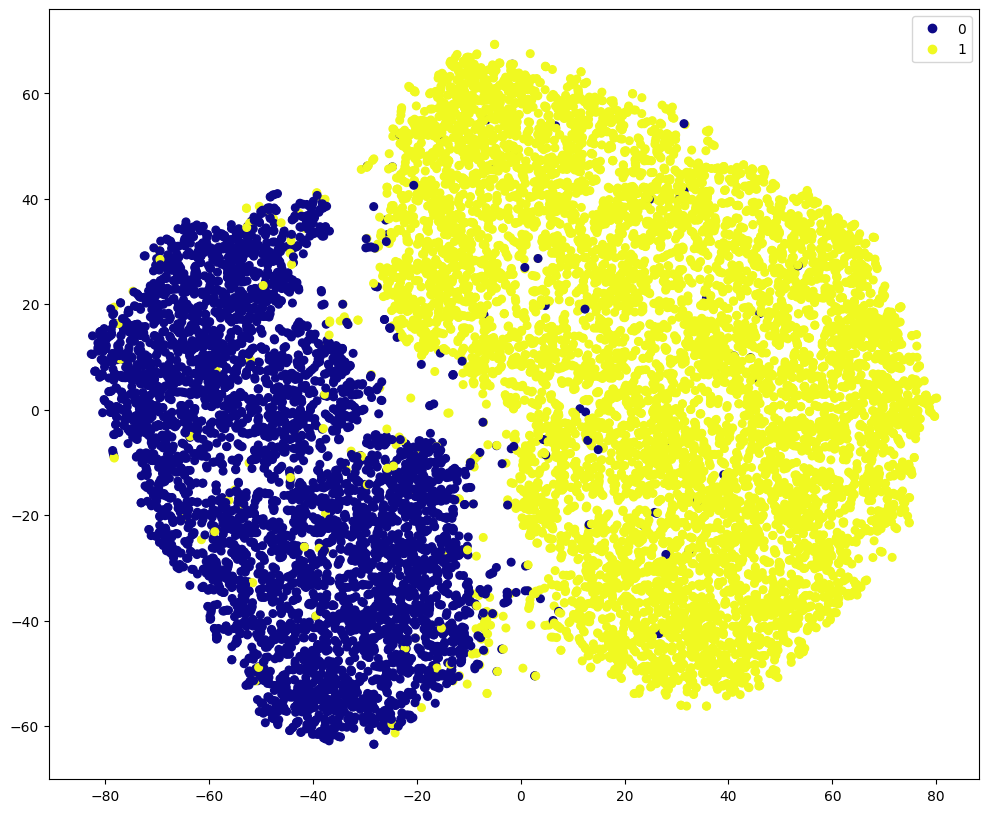

In [18]:
plt.figure(figsize=(12, 10))

sc = plt.scatter(x_tsne[:, 0], x_tsne[:,  1], c = y2, cmap='plasma', s = 30)
plt.legend(*sc.legend_elements())

plt.show()

In [ ]:
# 결과 확인 -> kl_divergence_ : 고차원과 저차원 확률 분포의 차이 (작을수록 좋음 )
tsne.kl_divergence_

2.415498733520508